In [1]:
from langchain_openai import AzureChatOpenAI
from pydantic import BaseModel, Field
from dotenv import load_dotenv
load_dotenv()

True

In [2]:
import os
from pyprojroot import here

os.chdir(here())

In [3]:
from coeur.score import Coeur

import pandas as pd
from tqdm.notebook import tqdm
from matplotlib import pyplot as plt

# Utils

In [4]:
llm = AzureChatOpenAI(
    azure_deployment="gpt-4.1",
    api_version="2025-01-01-preview",
    temperature=0,
    max_tokens=2000,
    timeout=None,
    max_retries=2
)

In [5]:
class Interesting(BaseModel):
     interesting: bool = Field(
        description="Indicates whether the input text is valuable to write a user story or not. True if it is valuable, False otherwise."
    )

class UserStory(BaseModel):
    epic: str = Field(
        description="An epic is a high-level feature or capability of the system. Multiple user stories can be grouped under the same epic."
    )
    description: str = Field(
        min_length=20,
        max_length=500,
        pattern=r"^As a .+, I want .+, so that .+$",
        examples=[
            "As a user, I want to log in, so that I can access my profile.",
            "As a product owner, I want to prioritize the backlog, so that the team works on the most valuable tasks."
        ],
        description="A user story is a description of a feature from an end-user perspective." + \
            "It should follow the 'As a [role], I want [feature], so that [benefit]' format." + \
            "Additionnaly, it should be between 20 and 500 characters long." 
    )

In [6]:
specs_path = os.path.join('datasets', 'trident', 'trident_specs.pdf')
backlog_path = os.path.join('datasets', 'trident', 'trident_backlog.csv')

# ICL Experiment

We provide the model with $d$ the project context, and $e$ the current epic story title in order to limit the generation scope. We setup four experiments:
1. Context ($d$) and epic ($e$)
2. No context ($d$) and no epic ($e$)
3. Context ($d$) and no epic ($e$)
4. No context ($d$) and epic ($e$)

In [7]:
coeur = Coeur(random_state=42, lemmatization=True, remove_stopwords=True, stemming=True,
              remove_re_se_stopwords=True)

R, B = coeur.load_data(ref_path=specs_path, cand_path=backlog_path, ref_mode="pdf", cand_mode="csv")

print(f"Reference length: {len(R)} chars")
print(f"Total stories: {len(B)}")

Reference length: 6964 chars
Total stories: 52


### 0. Helpers

In [8]:
interesting_evaluator_prompt = """
Considering the following software specifications chunk, and the list of available epic story titles, 
determine if the chunk of specification that is provided sufficient information to write at least one user story from it.

Specifications Chunk:
{specs_chunk}

Return True if it is interesting, False otherwise.
"""

In [9]:
def generate_B(R: str, B: pd.DataFrame, llm: AzureChatOpenAI, max_iter=5, check_prompt="", generation_prompt="") -> pd.DataFrame:
    chunk_size = max(1, len(R) // max_iter)
    
    R_chunks = [R[i: i+chunk_size] for i in range(0, len(R), chunk_size)]
    epics_titles = B.epic.unique()

    y_pred = []

    for i in tqdm(range(max_iter)):
        if check_prompt != "":
            interesting = llm.with_structured_output(Interesting).invoke(
                check_prompt.format(
                    specs_chunk=R_chunks[i%max_iter]
                )
            )
        else:
            interesting = Interesting(interesting=True)

        if not interesting.interesting:
            print(f"Specifications chunk {i+1} deemed uninteresting, skipping...")
            continue

        us = llm.with_structured_output(UserStory).invoke(
            generation_prompt.format(
                specs_chunk=R_chunks[i],
                epic_titles=epics_titles,
                existing_user_stories="\n".join(["Epic: " + us["epic"] + "|| Story: " + us["user_story"] for us in y_pred])
            )
        )

        y_pred.append({"epic": us.epic, "user_story": us.description})
    B_pred = pd.DataFrame(y_pred)
    return B_pred

In [28]:
def iterative_coeur(B: pd.DataFrame, cs_offset=10, sigma="ROUGE-2 Precision", l="s"):
    # Iterative Calculation
    results = []
    coeur = Coeur(random_state=42, lemmatization=True, remove_stopwords=True, stemming=True,
              remove_re_se_stopwords=True)

    for i in tqdm(range(cs_offset, len(B) + 1)):
        current_backlog = B.iloc[:i]
        
        scores = coeur.score(R=R, B=current_backlog, sigma=sigma, l=l)
        scores['n_stories'] = i
        results.append(scores)
        
    # Create DataFrame from results
    df_results = pd.DataFrame(results)
    return df_results

def plot_iterative_coeur(df_results):
    plt.figure(figsize=(10, 6))
    plt.plot(df_results['n_stories'], df_results['COEUR'], label='COEUR', marker='o', markersize=3)
    plt.plot(df_results['n_stories'], df_results['Cohesion'], label='Cohesion', linestyle='--')
    plt.plot(df_results['n_stories'], df_results['Exhaustiveness'], label='Exhaustiveness', linestyle='--')

    plt.xlabel('Number of User Stories')
    plt.ylabel('Score')
    plt.title('COEUR Evolution with Increasing Backlog Size')
    plt.legend()
    plt.grid(True)
    plt.show()

def plot_multiple_iterative_coeur(mean_results, std_results):
    plt.figure(figsize=(10, 6))
    plt.plot(mean_results['n_stories'], mean_results['COEUR'], label='COEUR', marker='o', markersize=3)
    plt.fill_between(mean_results['n_stories'],
                     mean_results['COEUR'] - std_results['COEUR'],
                     mean_results['COEUR'] + std_results['COEUR'],
                     alpha=0.2)

    plt.plot(mean_results['n_stories'], mean_results['Cohesion'], label='Cohesion', linestyle='--')
    plt.fill_between(mean_results['n_stories'],
                     mean_results['Cohesion'] - std_results['Cohesion'],
                     mean_results['Cohesion'] + std_results['Cohesion'],
                     alpha=0.2)

    plt.plot(mean_results['n_stories'], mean_results['Exhaustiveness'], label='Exhaustiveness', linestyle='--')
    plt.fill_between(mean_results['n_stories'],
                     mean_results['Exhaustiveness'] - std_results['Exhaustiveness'],
                     mean_results['Exhaustiveness'] + std_results['Exhaustiveness'],
                     alpha=0.2)

    plt.xlabel('Number of User Stories')
    plt.ylabel('Score')
    plt.title('COEUR Evolution with Increasing Backlog Size')
    plt.legend()
    plt.grid(True)
    plt.show()

def load_results(dataset_name: str, strategy_name: str):
    results_dir = os.path.join('experiments', 'llm_validation', 'output', dataset_name)

    mean_path = os.path.join(results_dir, f'mean_results_{strategy_name}.csv')
    std_path = os.path.join(results_dir, f'std_results_{strategy_name}.csv')

    mean_results = pd.read_csv(mean_path)
    std_results = pd.read_csv(std_path)
    return mean_results, std_results

def compare_coeur_strategies(dataset_name: str, strategy_names: list[str], metric: str = "COEUR"):
    plt.figure(figsize=(10, 6))

    for strategy_name in strategy_names:
        mean_results, std_results = load_results(dataset_name, strategy_name)
        
        plt.plot(mean_results['n_stories'], mean_results[metric], label=strategy_name, marker='o', markersize=3)
        plt.fill_between(mean_results['n_stories'],
                         mean_results[metric] - std_results[metric],
                         mean_results[metric] + std_results[metric],
                         alpha=0.2)

    plt.xlabel('Number of User Stories')
    plt.ylabel(f'{metric} Score')
    plt.title(f'Comparison of {metric} Evolution Across Strategies')
    plt.legend()
    plt.grid(True)
    plt.show()

### 1. Context ($d$) and epic ($e$)

In [ ]:
context_epic_prompt = """
Given the following software specifications chunk and the list of epic titles it is attached to you have two tasks :
    1. Determine which epic title the specifications chunk is best suited for.
    2. Generate a user story fitting the epic and the specifications chunk.
You must not try to encapsulate all the specifications and epic in a single user story, but rather focus on a specific feature or functionality that would be valuable to an end-user.

Specifications Chunk :
{specs_chunk}

List of Epic Titles :
{epic_titles}
"""

In [ ]:
B_pred = generate_B(R, B, llm, max_iter=30, 
                    check_prompt=interesting_evaluator_prompt,
                    generation_prompt=context_epic_prompt)

  0%|          | 0/30 [00:00<?, ?it/s]

Specifications chunk 8 deemed uninteresting, skipping...
Specifications chunk 14 deemed uninteresting, skipping...


In [15]:
B_pred_shuffle = B_pred.sample(frac=1).reset_index(drop=True)

  0%|          | 0/24 [00:00<?, ?it/s]

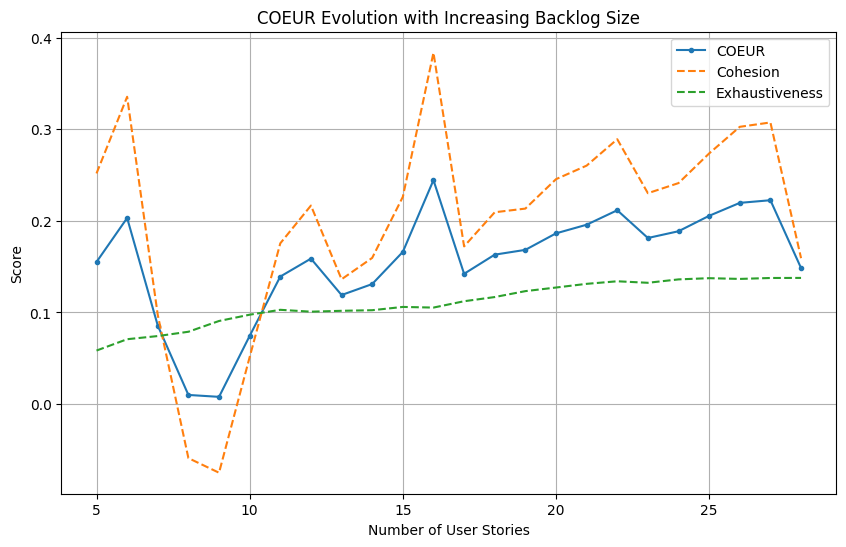

In [19]:
context_epic_results = iterative_coeur(B_pred_shuffle, cs_offset=5, sigma="ROUGE-2 F1", l="b")
plot_iterative_coeur(context_epic_results)

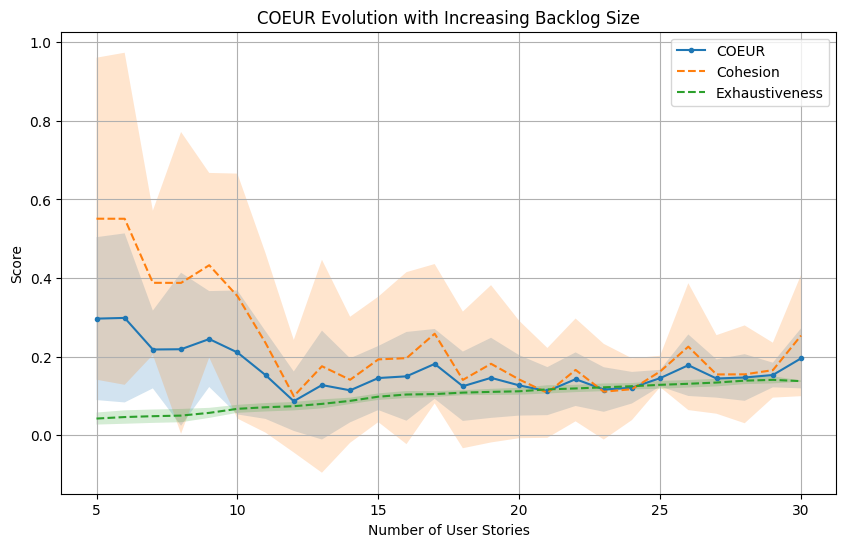

In [11]:
m, std = load_results("trident", "context_epic")
plot_multiple_iterative_coeur(m, std)

### 2. No Context ($d$) and No epic ($e$)

In [10]:
# no_context_no_epic_prompt = """
# Generate a user story based on the following rules:
# 1. If not epic stories exist, create yours
# 2. If epics exist, privilege creating user stories within existing epics.
# 3. If an epic contains enought user stories (between 3 and 10), create a new epic for the new user story.

# # Avoid redundant user stories with existing user stories that follows (format is "Epic: [epic] || Story: [story]"):
# # {existing_user_stories}
# """

# no_context_no_epic_prompt = """
# Generate a user story based on the theme of your choice.

# # Avoid redundant user stories with existing user stories that follows (format is "Epic: [epic] || Story: [story]"):
# # {existing_user_stories}
# """

no_context_no_epic_prompt = """
Generate a user story based on the theme of your choice.
"""

In [11]:
B_pred = generate_B(R, B, llm, max_iter=30, 
                    check_prompt="",
                    generation_prompt=no_context_no_epic_prompt)

  0%|          | 0/30 [00:00<?, ?it/s]

In [12]:
B_pred_shuffle = B_pred.sample(frac=1).reset_index(drop=True)

In [13]:
B_pred_shuffle

,epic,user_story
0,Online Shopping Cart,"As a shopper, I want to add items to my cart, ..."
1,Online Shopping Cart,"As a shopper, I want to add items to my cart, ..."
2,Online Shopping Cart,"As a shopper, I want to add items to my cart, ..."
3,Online Shopping Cart,"As a shopper, I want to add items to my cart, ..."
4,Online Shopping Cart,"As a shopper, I want to add items to my cart, ..."
5,Online Shopping Cart,"As a shopper, I want to add items to my cart, ..."
6,Online Shopping Cart,"As a shopper, I want to add items to my cart, ..."
7,Online Shopping Cart,"As a shopper, I want to add items to my cart, ..."
8,Online Shopping Cart,"As a shopper, I want to add items to my cart, ..."
9,Online Shopping Cart,"As a shopper, I want to add items to my cart, ..."


  0%|          | 0/26 [00:00<?, ?it/s]

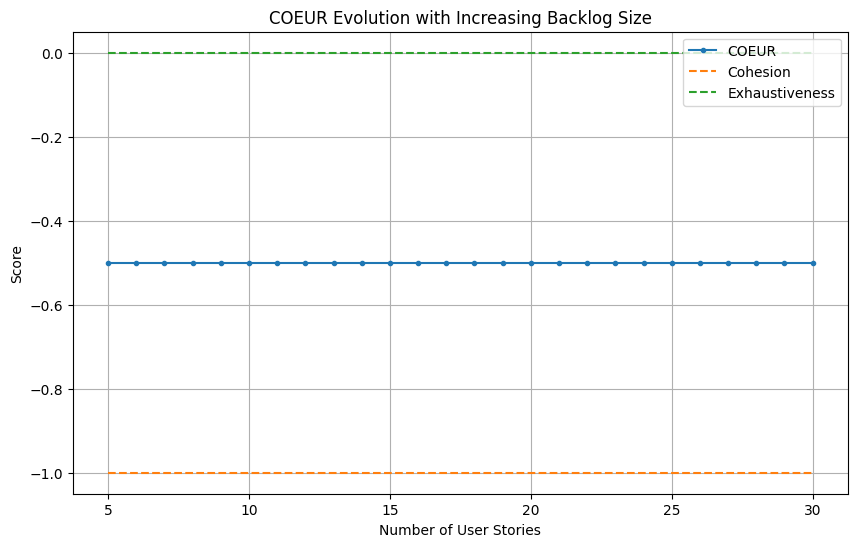

In [14]:
no_context_no_epic_results = iterative_coeur(B_pred_shuffle, cs_offset=5, sigma="ROUGE-2 F1", l="b")
plot_iterative_coeur(no_context_no_epic_results)

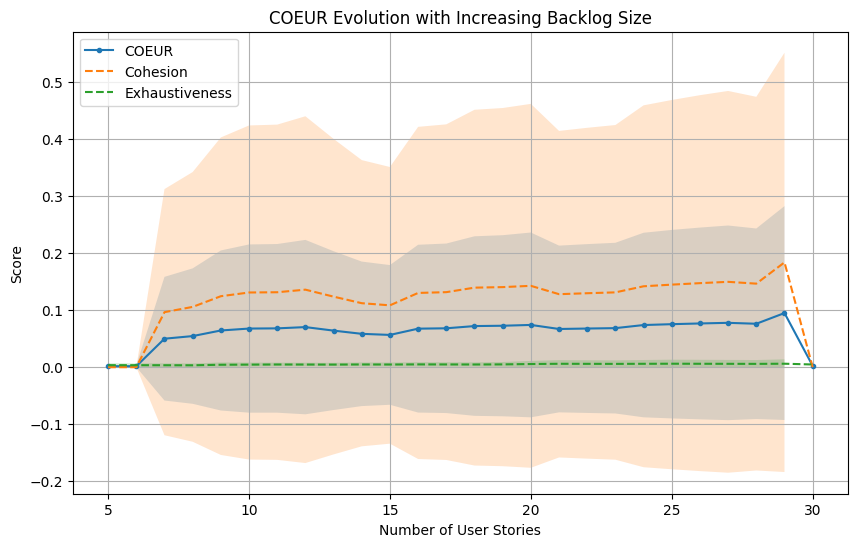

In [12]:
m, std = load_results("trident", "no_context_no_epic")
plot_multiple_iterative_coeur(m, std)

### 3. Context ($d$) and No epic ($e$)

In [10]:
context_no_epic_prompt = """
Given the following software specifications chunk, generate a user story that captures a specific feature or functionality described in the text.
You will also need to assign an appropriate epic title to this user story.

Specifications Chunk :
{specs_chunk}
"""

B_pred = generate_B(R, B, llm, max_iter=30, 
                    check_prompt=interesting_evaluator_prompt,
                    generation_prompt=context_no_epic_prompt)

  0%|          | 0/30 [00:00<?, ?it/s]

Specifications chunk 8 deemed uninteresting, skipping...
Specifications chunk 14 deemed uninteresting, skipping...


In [12]:
B_pred

,epic,user_story
0,Item Management,"As a repository manager, I want items with com..."
1,Item Relationships Management,"As a user, I want to define relationships betw..."
2,Workflow Management,"As a project manager, I want to assign custom ..."
3,Component Management,"As a user, I want each component to be associa..."
4,Repository Relationships Management,"As a repository manager, I want to define rela..."
5,Bidirectional Linking and Relationships,"As a user, I want to create bidirectional link..."
6,Item Set Management,"As a user, I want to view sets of items based ..."
7,Collection Management,"As a user, I want each item to be associated w..."
8,Collection and Category Management,"As a user, I want to assign multiple categorie..."
9,Category Management,"As a user, I want to associate a metadata prof..."


  0%|          | 0/24 [00:00<?, ?it/s]

/home/m.ortega/repositories/coeur-cohesion-and-exhaustiveness-of-user-story-representations/.venv/lib/python3.10/site-packages/sklearn/metrics/cluster/_supervised.py:49: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_label = type_of_target(labels_true)
/home/m.ortega/repositories/coeur-cohesion-and-exhaustiveness-of-user-story-representations/.venv/lib/python3.10/site-packages/sklearn/metrics/cluster/_supervised.py:50: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_pred = type_of_target(labels_pred)
/home/m.ortega/repositories/coeur-cohesion-and-exhaustiveness-of-user-story-representations/.venv/lib/python3.10/site-packages/sklearn/metrics/cluster/_supervised.py:49: UserWarning: The number of unique classes is greater than 50% of the number of sample

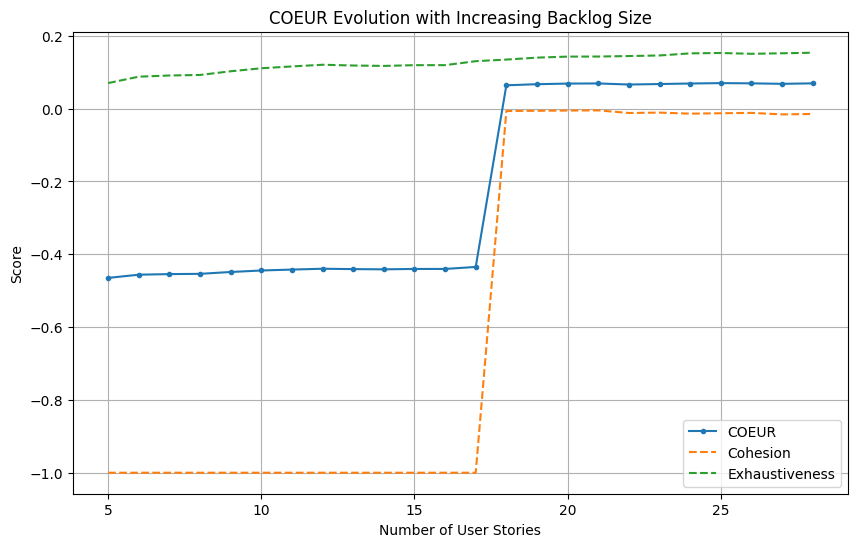

In [13]:
B_pred_shuffle = B_pred.sample(frac=1).reset_index(drop=True)

context_no_epic_results = iterative_coeur(B_pred_shuffle, cs_offset=5, sigma="ROUGE-2 F1", l="b")
plot_iterative_coeur(context_no_epic_results)

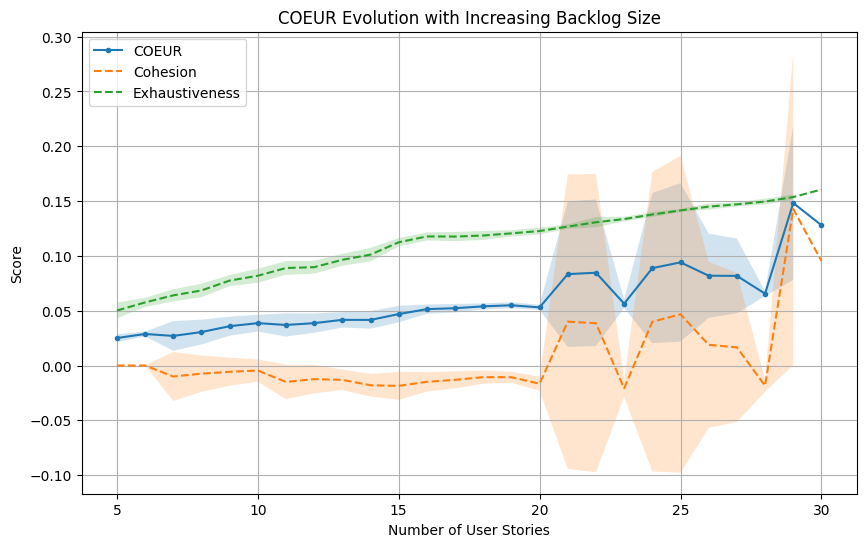

In [13]:
m, std = load_results("trident", "context_no_epic")
plot_multiple_iterative_coeur(m, std)

### 4. No Context ($d$) and epic ($e$)

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/26 [00:00<?, ?it/s]

/home/m.ortega/repositories/coeur-cohesion-and-exhaustiveness-of-user-story-representations/.venv/lib/python3.10/site-packages/sklearn/metrics/cluster/_supervised.py:49: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_label = type_of_target(labels_true)
/home/m.ortega/repositories/coeur-cohesion-and-exhaustiveness-of-user-story-representations/.venv/lib/python3.10/site-packages/sklearn/metrics/cluster/_supervised.py:50: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_pred = type_of_target(labels_pred)
/home/m.ortega/repositories/coeur-cohesion-and-exhaustiveness-of-user-story-representations/.venv/lib/python3.10/site-packages/sklearn/metrics/cluster/_supervised.py:49: UserWarning: The number of unique classes is greater than 50% of the number of sample

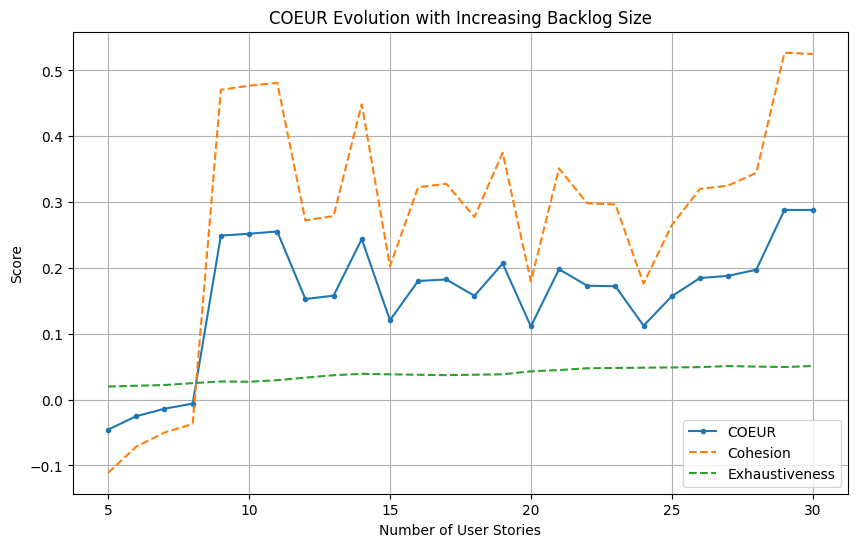

In [10]:
no_context_epic_prompt = """
Generate a user story that fits into one of the provided epic titles.

List of Epic Titles :
{epic_titles}

# Avoid redundant user stories with existing user stories that follows (format is "Epic: [epic] || Story: [story]"):
# {existing_user_stories}
"""

B_pred = generate_B(R, B, llm, max_iter=30, 
                    check_prompt="",
                    generation_prompt=no_context_epic_prompt)

B_pred_shuffle = B_pred.sample(frac=1).reset_index(drop=True)

no_context_epic_results = iterative_coeur(B_pred_shuffle, cs_offset=5, sigma="ROUGE-2 F1", l="b")
plot_iterative_coeur(no_context_epic_results)

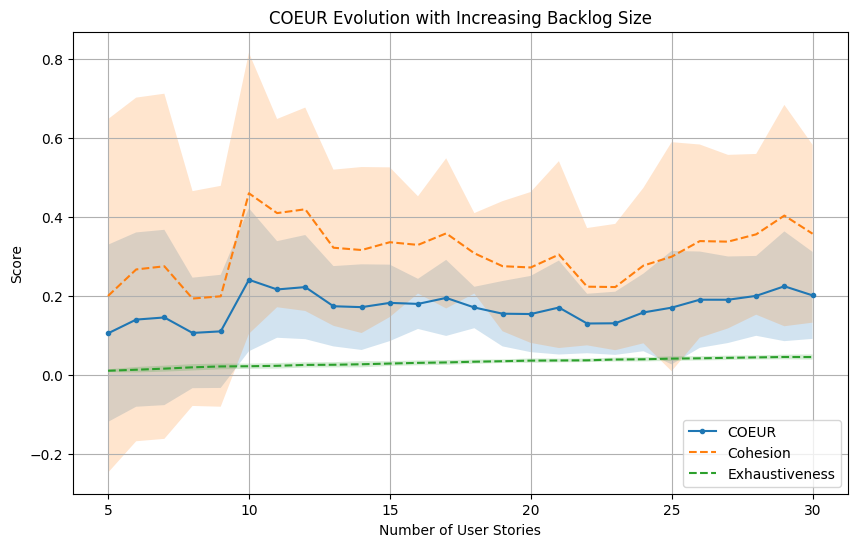

In [14]:
m, std = load_results("trident", "no_context_epic")
plot_multiple_iterative_coeur(m, std)

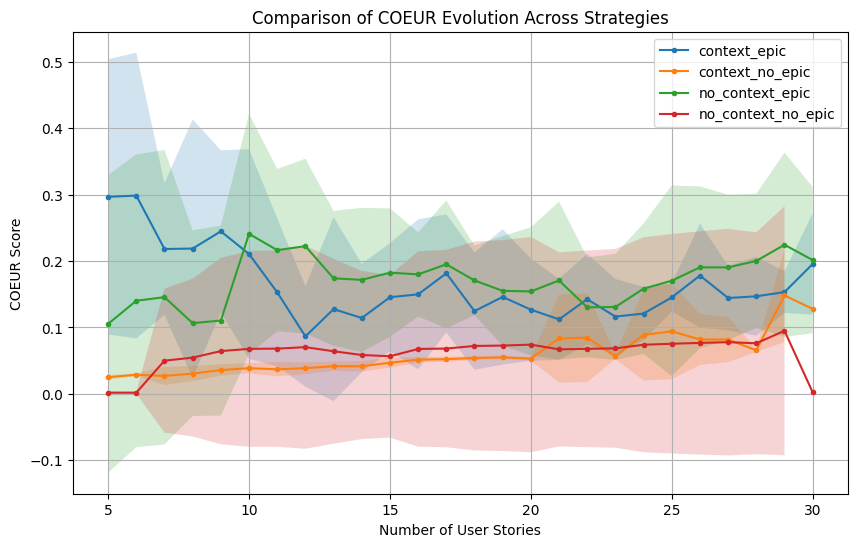

In [17]:
compare_coeur_strategies("trident", 
                         ["context_epic", "context_no_epic", "no_context_epic", "no_context_no_epic"])

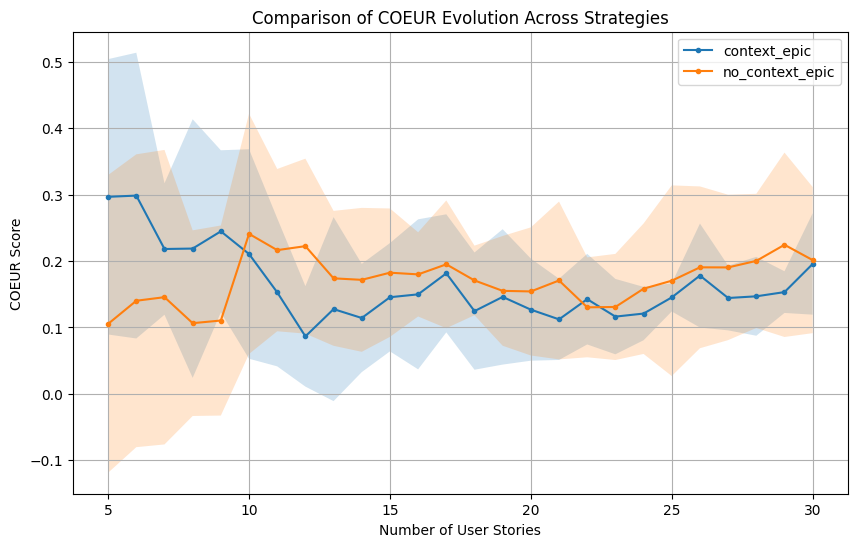

In [34]:
compare_coeur_strategies("trident", 
                         ["context_epic", "no_context_epic"])

# Visualizations

### Trident

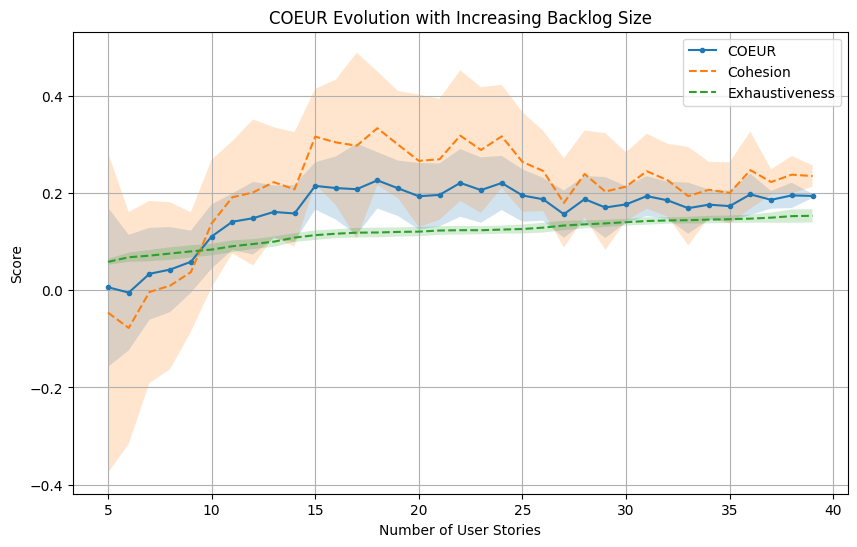

In [11]:
m, std = load_results("trident", "context_epic")
plot_multiple_iterative_coeur(m, std)

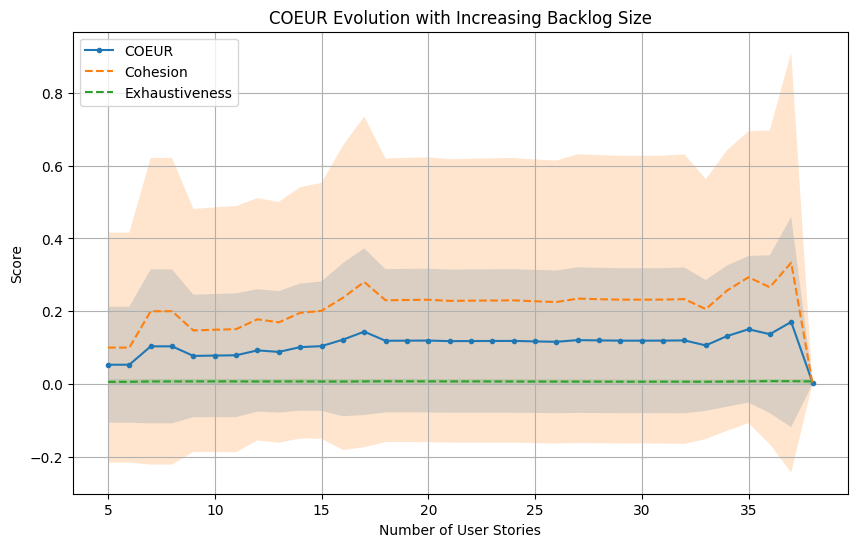

In [12]:
m, std = load_results("trident", "no_context_no_epic")
plot_multiple_iterative_coeur(m, std)

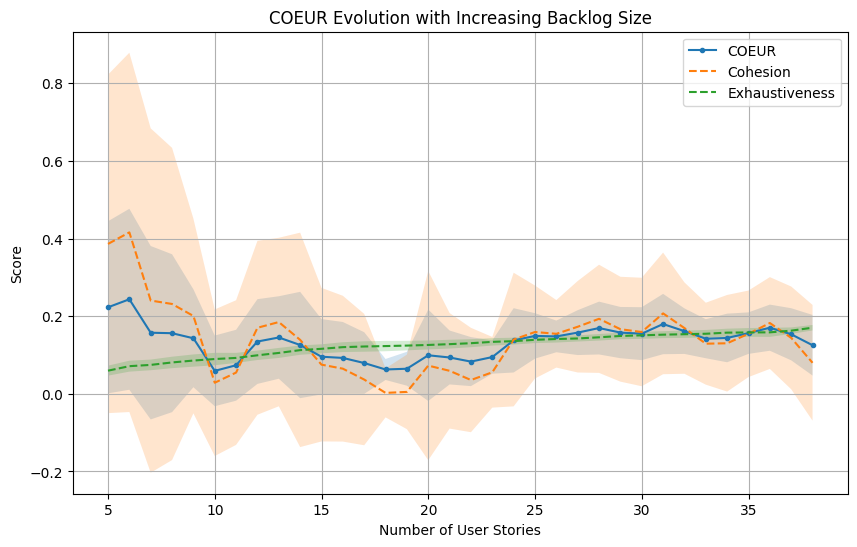

In [13]:
m, std = load_results("trident", "context_no_epic")
plot_multiple_iterative_coeur(m, std)

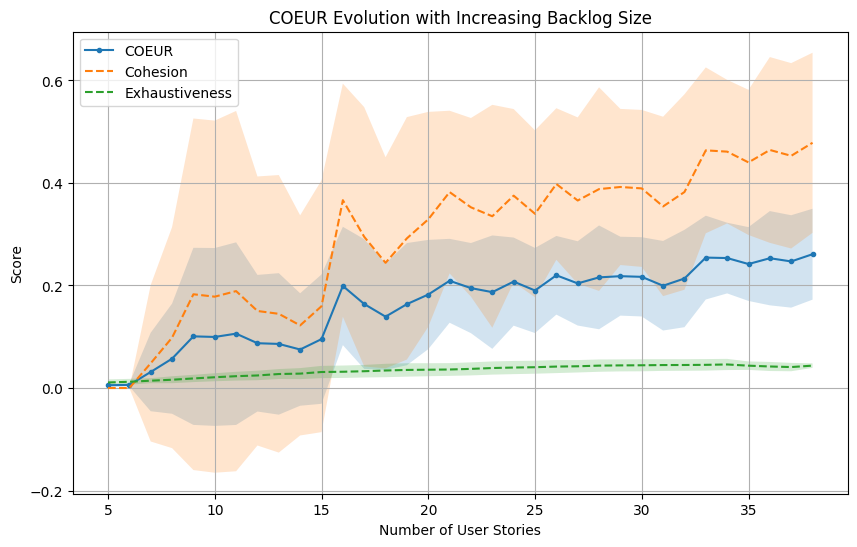

In [14]:
m, std = load_results("trident", "no_context_epic")
plot_multiple_iterative_coeur(m, std)

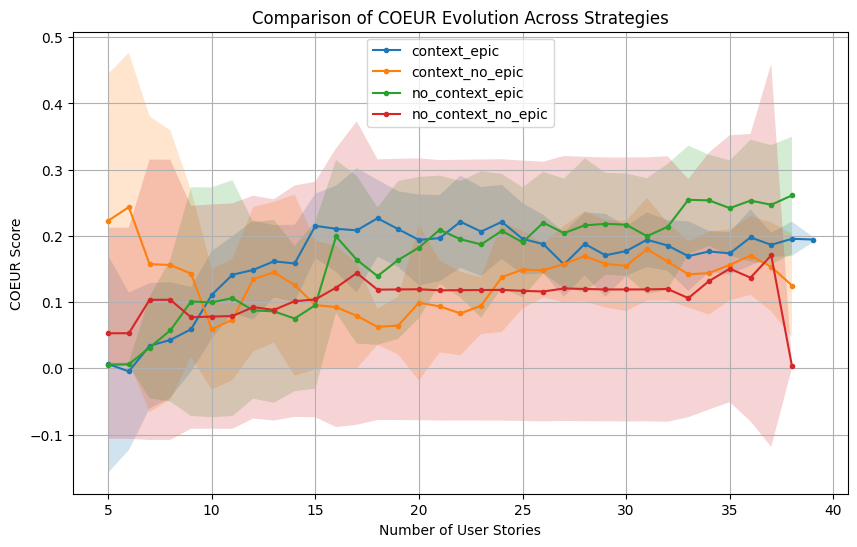

In [33]:
compare_coeur_strategies("trident", 
                         ["context_epic", "context_no_epic", "no_context_epic", "no_context_no_epic"],
                         metric="COEUR")

### Retro

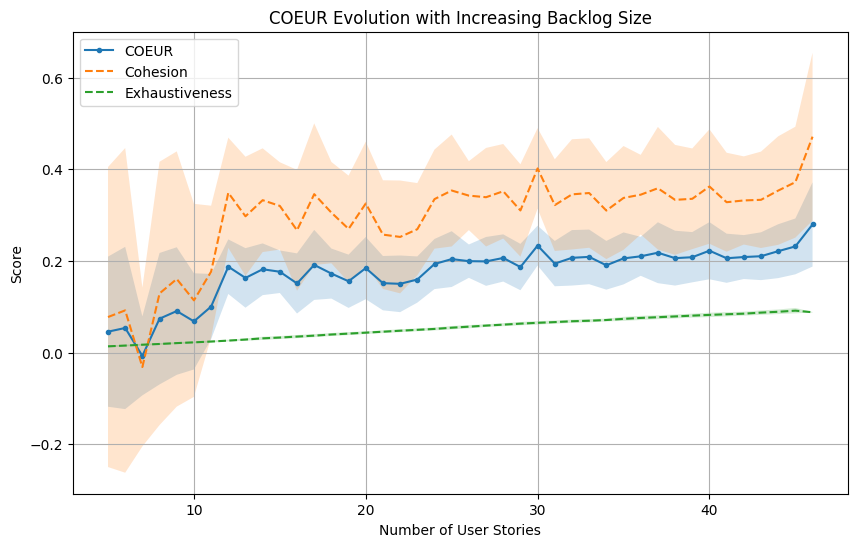

In [16]:
m, std = load_results("retro", "context_epic")
plot_multiple_iterative_coeur(m, std)

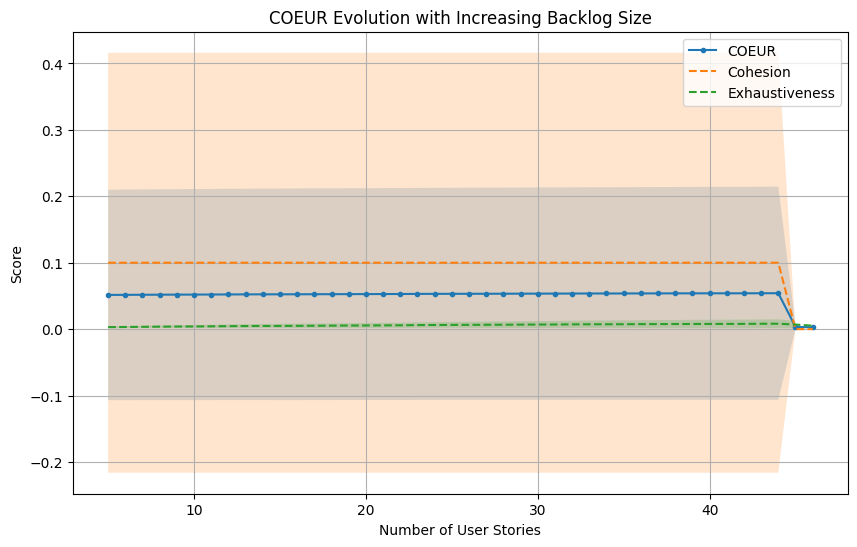

In [17]:
m, std = load_results("retro", "no_context_no_epic")
plot_multiple_iterative_coeur(m, std)

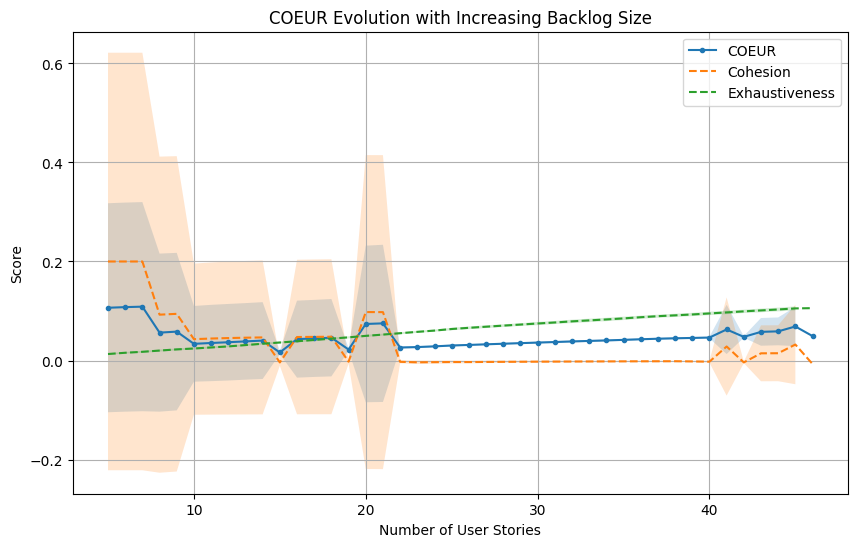

In [18]:
m, std = load_results("retro", "context_no_epic")
plot_multiple_iterative_coeur(m, std)

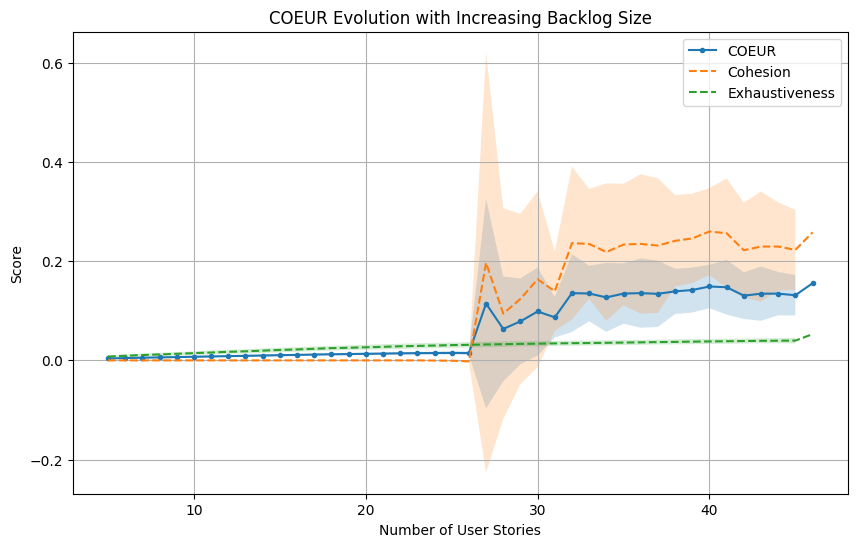

In [19]:
m, std = load_results("retro", "no_context_epic")
plot_multiple_iterative_coeur(m, std)

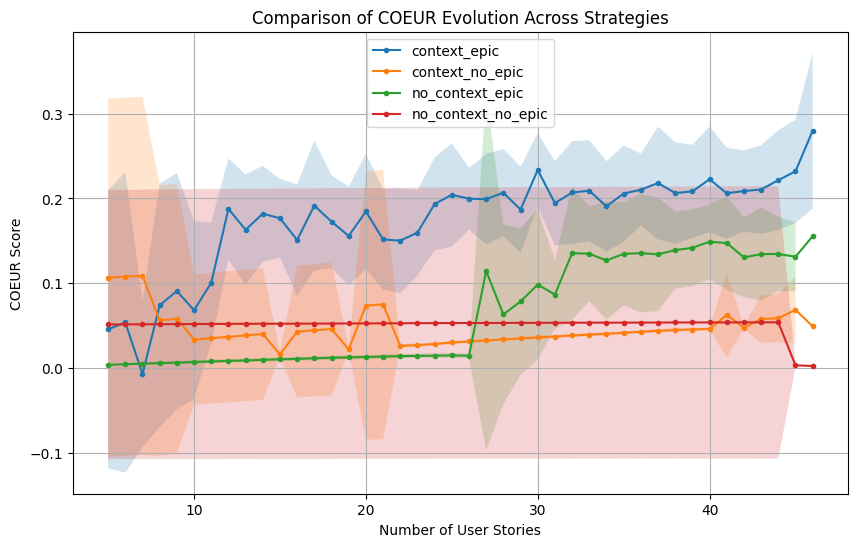

In [20]:
compare_coeur_strategies("retro", 
                         ["context_epic", "context_no_epic", "no_context_epic", "no_context_no_epic"])

### Alfred

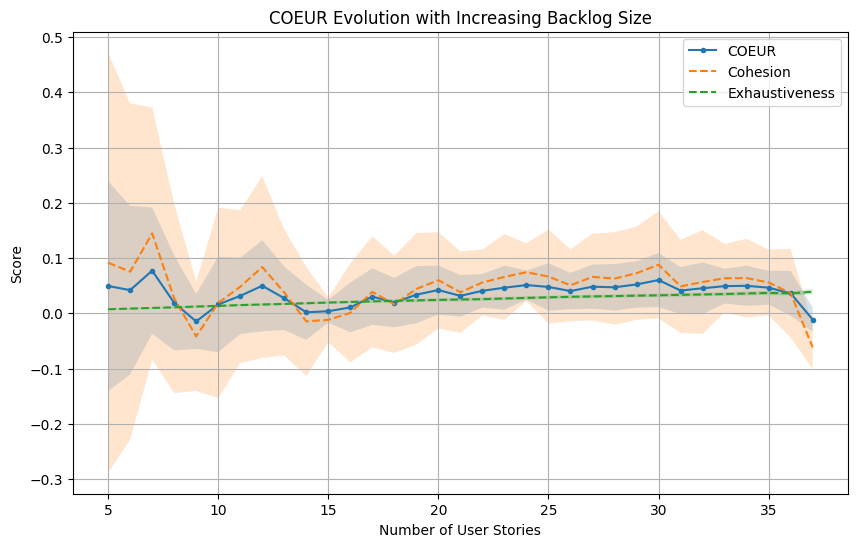

In [24]:
m, std = load_results("alfred", "context_epic")
plot_multiple_iterative_coeur(m, std)

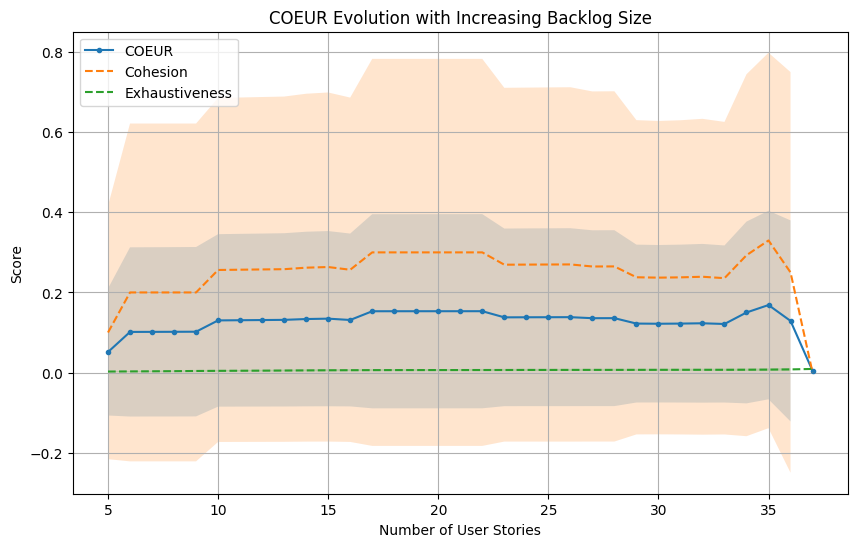

In [25]:
m, std = load_results("alfred", "no_context_no_epic")
plot_multiple_iterative_coeur(m, std)

In [ ]:
m, std = load_results("alfred", "context_no_epic")
plot_multiple_iterative_coeur(m, std)

In [ ]:
m, std = load_results("alfred", "no_context_epic")
plot_multiple_iterative_coeur(m, std)

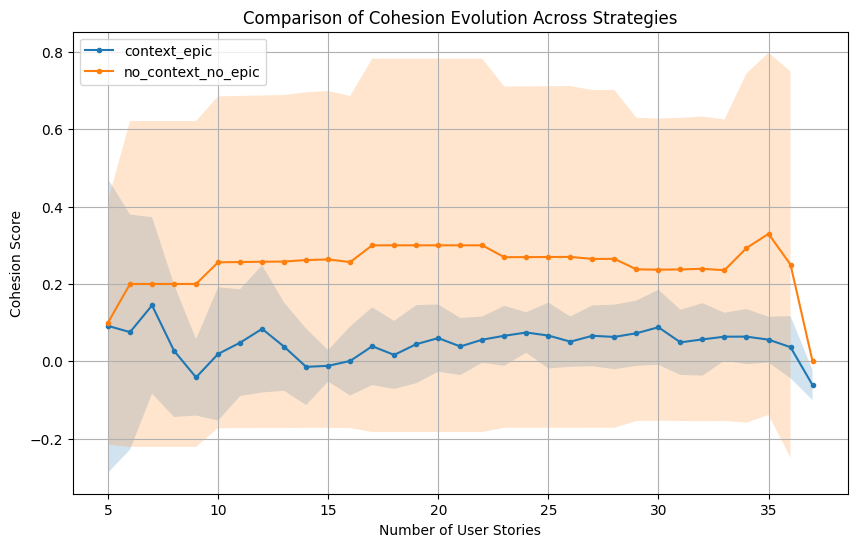

In [36]:
compare_coeur_strategies("alfred", 
                         ["context_epic", "no_context_no_epic"],
                         metric="Cohesion")

### Recapitulation of results